In [1]:
!ls /kaggle/input
!ls /kaggle/input/understanding_cloud_organization

understanding_cloud_organization
sample_submission.csv  test_images  train.csv  train_images


In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import models

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import os

In [3]:
torch.cuda.is_available()

True

In [4]:
train = pd.read_csv('/kaggle/input/understanding_cloud_organization/train.csv')

(np.float64(-0.5), np.float64(2099.5), np.float64(1399.5), np.float64(-0.5))

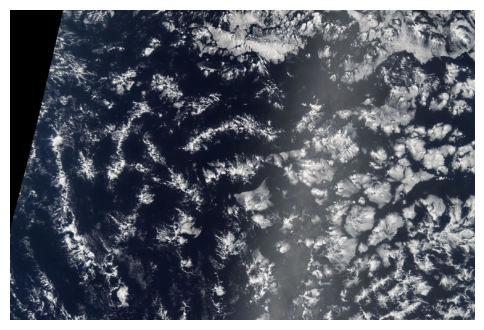

In [5]:
img_name = train["Image_Label"].iloc[0].split("_")[0]
img = Image.open(f"/kaggle/input/understanding_cloud_organization/train_images/{img_name}")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")

In [6]:
train["image"] = train["Image_Label"].apply(lambda x: x.split("_")[0])
train["label"] = train["Image_Label"].apply(lambda x: x.split("_")[1])

images = train["image"].unique().tolist()
CLASSES = ["Fish", "Flower", "Gravel", "Sugar"]

In [7]:
def rle_decode(rle, shape):
    if pd.isna(rle):
        return np.zeros(shape, dtype=np.uint8)

    s = list(map(int, rle.split()))
    starts, lengths = s[0::2], s[1::2]
    starts = np.array(starts) - 1

    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for start, length in zip(starts, lengths):
        img[start:start + length] = 1

    return img.reshape(shape, order="F")

In [8]:
class CloudDataset(Dataset):
    def __init__(self, df, image_dir="/kaggle/input/understanding_cloud_organization/train_images", classes=CLASSES):
        self.df = df
        self.image_dir = image_dir
        self.classes = classes
        self.images = df["image"].unique().tolist()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)

        img = np.array(Image.open(img_path).convert("RGB"))
        H, W = img.shape[:2]

        masks = []
        for cls in self.classes:
            rle = self.df.loc[
                self.df["Image_Label"] == f"{img_name}_{cls}",
                "EncodedPixels"
            ].values[0]
            masks.append(rle_decode(rle, (H, W)))

        mask = np.stack(masks, axis=0)

        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mask_t = torch.from_numpy(mask).float()

        return img_t, mask_t

In [9]:
train_dataset = CloudDataset(train)

In [10]:
def show_cloud_samples(dataset, n_images=3, classes=CLASSES):
    fig, axes = plt.subplots(n_images, len(classes)+1,
                             figsize=(4*(len(classes)+1), 4*n_images))

    for i in range(n_images):
        img, mask = dataset[i]

        img_np = img.permute(1,2,0).numpy()

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        for j, cls in enumerate(classes):
            axes[i, j+1].imshow(mask[j].numpy(), cmap="gray")
            axes[i, j+1].set_title(cls)
            axes[i, j+1].axis("off")

    plt.tight_layout()
    plt.show()

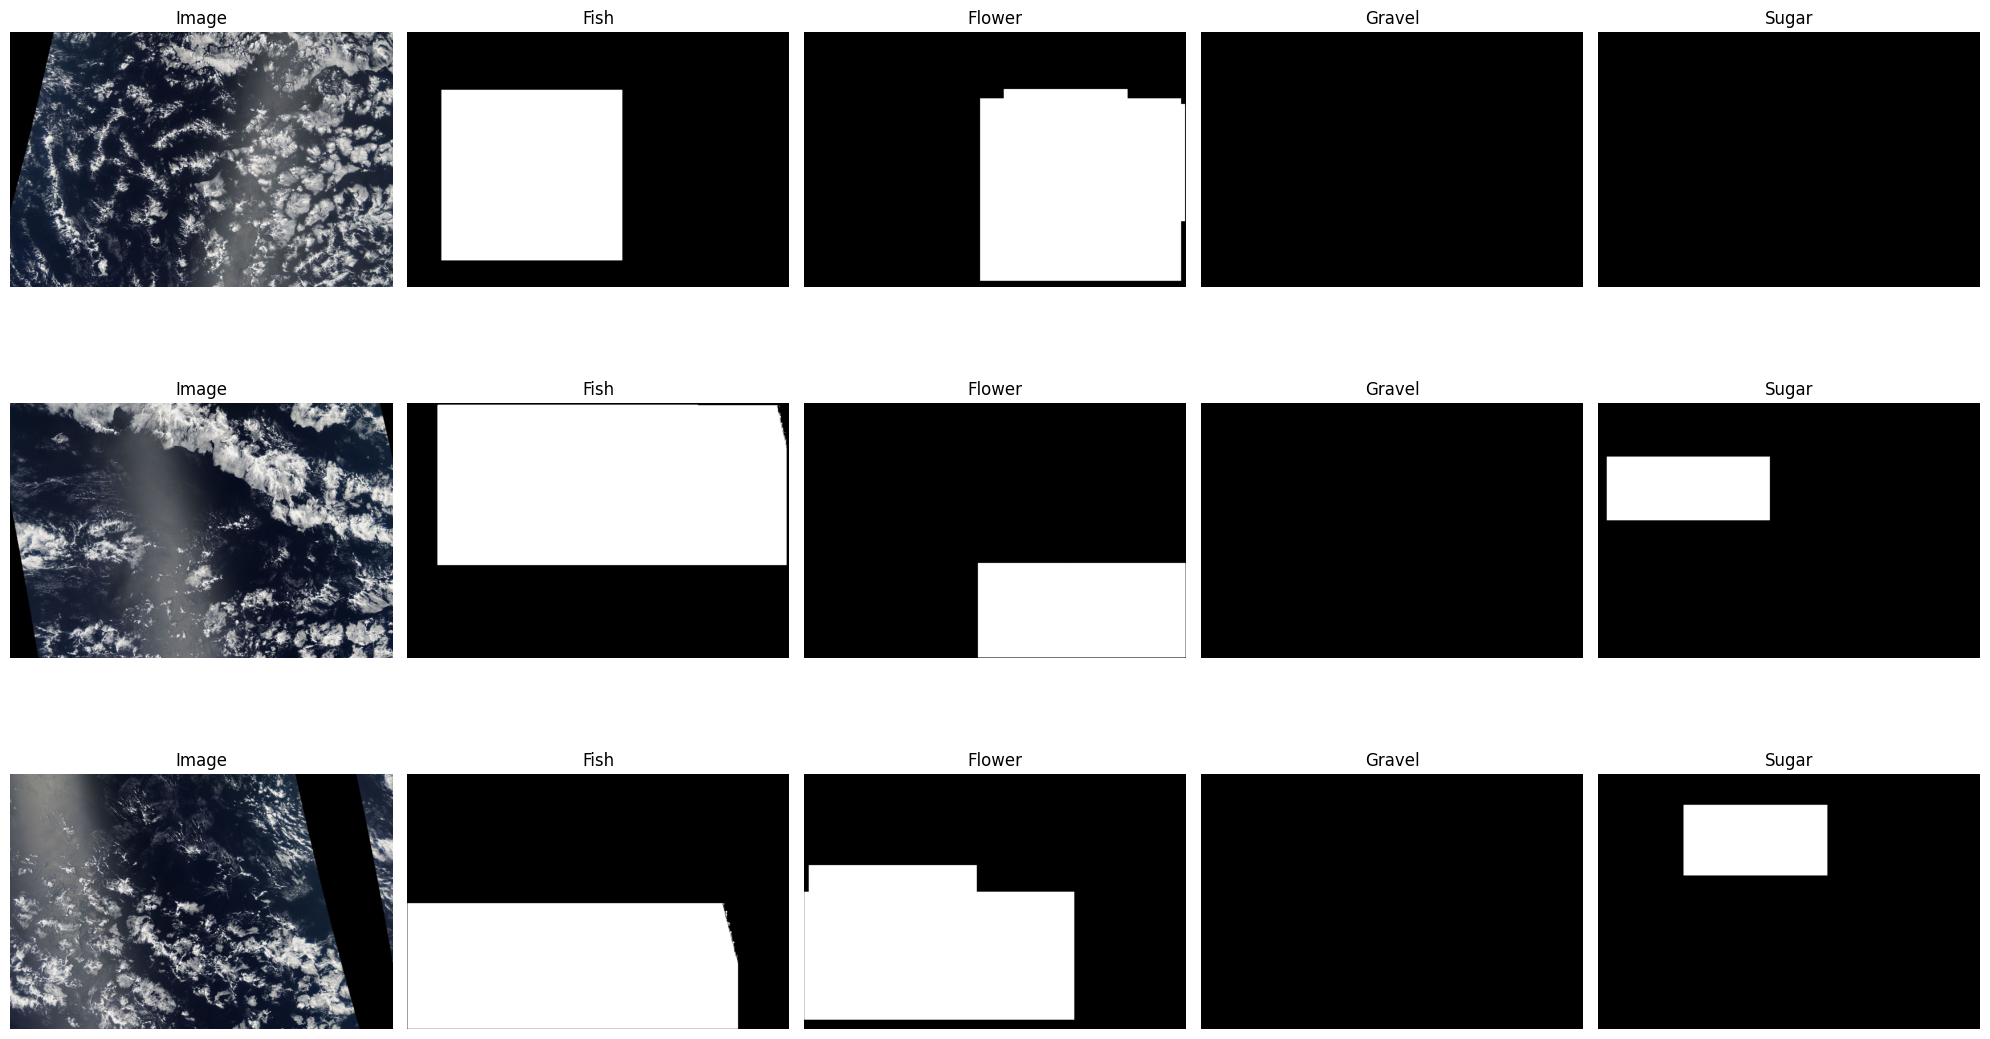

In [17]:
show_cloud_samples(train_dataset)

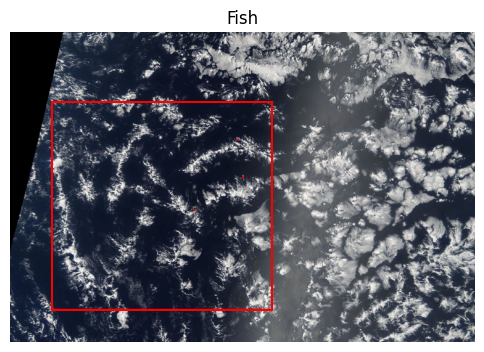

In [11]:
img, mask = train_dataset[0]

import matplotlib.pyplot as plt

j = 0

plt.figure(figsize=(6,6))
plt.imshow(img.permute(1,2,0).numpy())
plt.contour(mask[j].numpy(), colors='red', linewidths=1)
plt.title(CLASSES[j])
plt.axis("off")
plt.show()

### Подготовка тренировочного и валидационного датасета

In [12]:
train_imgs, val_imgs = train_test_split(
    images, test_size=0.2, random_state=42, shuffle=True
)

train_df = train[train["image"].isin(train_imgs)].reset_index(drop=True)
val_df   = train[train["image"].isin(val_imgs)].reset_index(drop=True)

print(len(train_imgs), len(val_imgs))

4436 1110


In [13]:
def build_mask(df_part, image_name, shape_hw):
    H, W = shape_hw
    masks = []
    for cls in CLASSES:
        rle = df_part.loc[
            df_part["Image_Label"] == f"{image_name}_{cls}",
            "EncodedPixels"
        ].values[0]
        masks.append(rle_decode(rle, (H, W)))
    return np.stack(masks, axis=-1)

In [14]:
train_transform = A.Compose([
    A.RandomResizedCrop(size=(384, 384), scale=(0.6, 1.0), ratio=(0.8, 1.2), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(384, 384),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [15]:
class CloudDataset(Dataset):
    def __init__(self, df_part, image_dir="/kaggle/input/understanding_cloud_organization/train_images", transform=None):
        self.df = df_part
        self.image_dir = image_dir
        self.transform = transform
        self.images = self.df["image"].unique().tolist()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)

        image = np.array(Image.open(img_path).convert("RGB"))
        H, W = image.shape[:2]

        mask = build_mask(self.df, img_name, (H, W))

        if self.transform is not None:
            out = self.transform(image=image, mask=mask)
            image = out["image"]
            mask  = out["mask"].permute(2,0,1)
        else:
            image = torch.from_numpy(image).permute(2,0,1).float() / 255.0
            mask  = torch.from_numpy(mask).permute(2,0,1).float()

        mask = mask.float()
        return image, mask

In [16]:
train_dataset = CloudDataset(train_df, transform=train_transform)
val_dataset   = CloudDataset(val_df, transform=val_transform)

In [18]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)

### Model 1

In [19]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        """
        logits: (B, C, H, W) — выход модели
        targets: (B, C, H, W) — 0/1 маски
        """
        probs = torch.sigmoid(logits)

        probs = probs.view(probs.size(0), probs.size(1), -1)
        targets = targets.view(targets.size(0), targets.size(1), -1)

        intersection = (probs * targets).sum(dim=2)
        dice = (2. * intersection + self.smooth) / (
            probs.sum(dim=2) + targets.sum(dim=2) + self.smooth
        )

        loss = 1 - dice
        return loss.mean()

In [20]:
import torch.nn.functional as F

class SimpleSegCNN(nn.Module):
    def __init__(self, in_ch=3, out_ch=4):
        super().__init__()
        # Encoder 
        self.conv1 = nn.Conv2d(in_ch, 16, kernel_size=3, stride=1, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        
        self.pool = nn.MaxPool2d(2, 2)

        # Decoder
        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)  
        self.bn_up1 = nn.BatchNorm2d(16)
        
        self.up2 = nn.ConvTranspose2d(16, 16, kernel_size=2, stride=2)  
        self.bn_up2 = nn.BatchNorm2d(16)

        self.drop = nn.Dropout2d(0.1)

        self.out = nn.Conv2d(16, out_ch, kernel_size=1)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # (B,16,192,192)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # (B,32,96,96)

        x = F.relu(self.bn_up1(self.up1(x))) # (B,16,192,192)
        x = self.drop(x)
        x = F.relu(self.bn_up2(self.up2(x))) # (B,16,384,384)

        x = self.out(x) # (B,4,384,384) logits
        return x

In [21]:
criterion = DiceLoss()
simple_model = SimpleSegCNN()
optimizer = torch.optim.Adam(simple_model.parameters(), lr=0.001)

In [23]:
def train_model(model, optimizer, num_epochs=5):
    model.train()
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}')

In [24]:
train_model(simple_model,optimizer)

Epoch 1, Loss: 0.7662
Epoch 2, Loss: 0.7426
Epoch 3, Loss: 0.7408
Epoch 4, Loss: 0.7391
Epoch 5, Loss: 0.7394


In [25]:
def dice_score(preds, targets, smooth=1.0):
   
    preds = preds.flatten(2)
    targets = targets.flatten(2)

    intersection = (preds * targets).sum(dim=2)
    dice = (2 * intersection + smooth) / (
        preds.sum(dim=2) + targets.sum(dim=2) + smooth
    )
    return dice  

In [32]:
def evaluate_segmentation(model, loader, threshold=0.5):
    model.eval()

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    dice_sum = torch.zeros(4, device=device)
    n_batches = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            dice = dice_score(preds, masks)  
            dice_sum += dice.mean(dim=0)
            n_batches += 1

    dice_per_class = dice_sum / n_batches
    mean_dice = dice_per_class.mean().item()

    return {
        "Fish":   dice_per_class[0].item(),
        "Flower": dice_per_class[1].item(),
        "Gravel": dice_per_class[2].item(),
        "Sugar":  dice_per_class[3].item(),
        "Mean":   mean_dice,
    }

In [33]:
metrics = evaluate_segmentation(simple_model, val_loader)

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Fish: 0.2444
Flower: 0.2123
Gravel: 0.2528
Sugar: 0.3126
Mean: 0.2555


In [ ]:
### TEST

In [34]:
class CloudTestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.image_ids = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, img_id)

        img = np.array(Image.open(img_path).convert("RGB"))

        if self.transform:
            aug = self.transform(image=img)
            img = aug["image"]          
        else:
            
            img = torch.from_numpy(img).permute(2,0,1).float() / 255.0

        return img, img_id

In [36]:
def rle_encode(mask):

    mask = mask.astype(np.uint8)
    if mask.sum() == 0:
        return ""

    pixels = mask.T.flatten()  
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(x) for x in runs)

In [40]:
CLASSES = ["Fish", "Flower", "Gravel", "Sugar"]

def predict_test_and_make_submission(model, test_loader, threshold=0.5):
    model.eval()
    rows = []

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    
    with torch.no_grad():
        for images, image_ids in test_loader:
            images = images.to(device)

            logits = model(images)                
            probs = torch.sigmoid(logits)          
            preds = (probs > threshold).float()    

            preds = preds.cpu().numpy().astype(np.uint8)

            for i, img_id in enumerate(image_ids):
                for c, cls in enumerate(CLASSES):
                    mask = preds[i, c]
                    rle = rle_encode(mask)
                    rows.append([f"{img_id}_{cls}", rle])

    sub = pd.DataFrame(rows, columns=["Image_Label", "EncodedPixels"])
    return sub

In [56]:
test_dir = "/kaggle/input/understanding_cloud_organization/test_images"

test_dataset = CloudTestDataset(test_dir, transform=val_transform) 
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=False)

sub_simple = predict_test_and_make_submission(simple_model, test_loader, threshold=0.5)

In [57]:
print(sub_simple.head(10))

          Image_Label                                      EncodedPixels
0    002f507.jpg_Fish  5 376 389 376 771 378 1155 378 1541 376 1925 3...
1  002f507.jpg_Flower  3 378 385 1 387 1 389 376 771 378 1155 378 154...
2  002f507.jpg_Gravel  1 380 385 380 769 380 1153 380 1541 376 1925 3...
3   002f507.jpg_Sugar  1 12 24 5 37 52 101 60 169 48 224 3 229 30 261...
4    0035ae9.jpg_Fish  5 377 383 2 389 380 773 376 1157 376 1541 376 ...
5  0035ae9.jpg_Flower  5 380 389 380 773 376 1157 376 1541 378 1925 3...
6  0035ae9.jpg_Gravel  5 376 389 376 773 376 1157 376 1541 376 1925 3...
7   0035ae9.jpg_Sugar  5 72 85 4 93 24 173 16 197 4 213 4 221 4 261 2...
8    0038327.jpg_Fish  5 376 389 376 773 376 1157 376 1541 376 1925 3...
9  0038327.jpg_Flower  5 376 389 376 773 376 1157 376 1541 376 1925 3...


### Model 2

In [44]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
       
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class UNetResNet18(nn.Module):
    def __init__(self, n_classes=4, pretrained=True):
        super().__init__()
        resnet = models.resnet18(pretrained=pretrained)

        # Encoder
        self.stem = nn.Sequential(
            resnet.conv1,  
            resnet.bn1,
            resnet.relu,
        )
        self.pool = resnet.maxpool  

        self.enc1 = resnet.layer1   
        self.enc2 = resnet.layer2   
        self.enc3 = resnet.layer3   
        self.enc4 = resnet.layer4    

     
        self.bridge = DoubleConv(512, 512)

    
        self.up4 = UpBlock(in_ch=512, skip_ch=256, out_ch=256)  
        self.up3 = UpBlock(in_ch=256, skip_ch=128, out_ch=128)  
        self.up2 = UpBlock(in_ch=128, skip_ch=64,  out_ch=64)  
        self.up1 = UpBlock(in_ch=64,  skip_ch=64,  out_ch=32) 

        self.up0 = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)  
        self.head = nn.Conv2d(32, n_classes, kernel_size=1)             

    def forward(self, x):
        # Encoder
        s0 = self.stem(x)           
        x  = self.pool(s0)        

        s1 = self.enc1(x)          
        s2 = self.enc2(s1)          
        s3 = self.enc3(s2)           
        s4 = self.enc4(s3)         

        # Bridge
        b = self.bridge(s4)         

        # Decoder
        x = self.up4(b,  s3)        
        x = self.up3(x,  s2)     
        x = self.up2(x,  s1)     
        x = self.up1(x,  s0)     

        x = self.up0(x)          
        logits = self.head(x)        
        return logits


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNetResNet18(n_classes=4, pretrained=False).to(device)
    x = torch.randn(2, 3, 384, 384).to(device)
    y = model(x)
    print("output:", y.shape)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


output: torch.Size([2, 4, 384, 384])


In [46]:
resnet_pretrained = UNetResNet18()
train_model(resnet_pretrained,optimizer)

Epoch 1, Loss: 0.8194
Epoch 2, Loss: 0.8194
Epoch 3, Loss: 0.8192
Epoch 4, Loss: 0.8197
Epoch 5, Loss: 0.8198


In [48]:
metrics = evaluate_segmentation(resnet_pretrained,val_loader)

for k, v in metrics.items():
    print(f'{k}: {v:.4f}')

Fish: 0.2177
Flower: 0.1842
Gravel: 0.0490
Sugar: 0.2004
Mean: 0.1628


In [51]:
sub_resnet = predict_test_and_make_submission(resnet_pretrained, test_loader, threshold=0.5)

In [52]:
sub_resnet.head(10)

,Image_Label,EncodedPixels
0,002f507.jpg_Fish,1 1 3 1 5 3 9 3 13 3 17 74 92 84 177 75 253 3 ...
1,002f507.jpg_Flower,1 24 26 23 50 9 60 1 62 7 70 11 82 7 90 31 122...
2,002f507.jpg_Gravel,385 1 389 1 435 1 439 1 472 1 487 1 511 1 523 ...
3,002f507.jpg_Sugar,1 2 4 1 8 1 12 3 16 1 20 1 22 1 24 1 26 1 28 1...
4,0035ae9.jpg_Fish,1 3 5 23 29 103 133 1 135 1 137 2 141 5 147 1 ...
5,0035ae9.jpg_Flower,2 11 14 3 18 31 50 3 54 3 58 31 90 1 92 17 110...
6,0035ae9.jpg_Gravel,237 1 276 1 385 1 389 1 394 1 407 1 411 1 495 ...
7,0035ae9.jpg_Sugar,2 1 4 1 6 1 12 1 14 1 16 1 18 1 22 1 24 1 26 1...
8,0038327.jpg_Fish,1 1 3 20 24 30 55 24 81 6 88 28 118 28 147 113...
9,0038327.jpg_Flower,1 34 36 121 158 51 210 11 222 5 228 25 254 67 ...


### Для более сложной предобученной модели (ResNet) функция потерь больше, чем для кастомной простой архитектуры, а dice coefficient в среднем меньше для всех масок. Возможно, данных недостаточно, поэтому более сложная модель дает результаты хуже, либо требует более тонких настроек.